In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

In [16]:
class KNN:

    def __init__(self, nb_features, nb_classes, data, k, weighted=False):
        self.nb_features = nb_features
        self.nb_classes = nb_classes
        self.k = k
        self.weighted = weighted
        self.X = tf.convert_to_tensor(data['x'], dtype=tf.float32)
        self.Y = tf.convert_to_tensor(data['y'], dtype=tf.int32)


    def predict(self, query_data):
        X_query = tf.convert_to_tensor(query_data['x'], dtype=tf.float32)
        Y_query = query_data['y']
        nb_queries = len(X_query)

        matches = 0
        predictions = []

        for i in range(nb_queries):
            dists = tf.norm(self.X - X_query[i], axis=1)
            _, idxs = tf.nn.top_k(-dists, self.k)
            classes = tf.gather(self.Y, idxs)

            if self.weighted:
                weights = 1 / tf.maximum(tf.gather(dists, idxs), 1e-9)
            else:
                weights = tf.fill([self.k], 1.0 / self.k)

            w_col = tf.reshape(weights, (self.k, 1))
            one_hot = tf.one_hot(classes, self.nb_classes)
            scores = tf.reduce_sum(w_col * one_hot, axis=0)
            hyp = tf.argmax(scores)
            predictions.append(hyp.numpy())

            if Y_query is not None and hyp == Y_query[i]:
                matches += 1

        accuracy = matches / nb_queries
        print(f'Test set accuracy: {accuracy:.2f}')
        return predictions

Test set accuracy: 0.76
Test set accuracy: 0.00


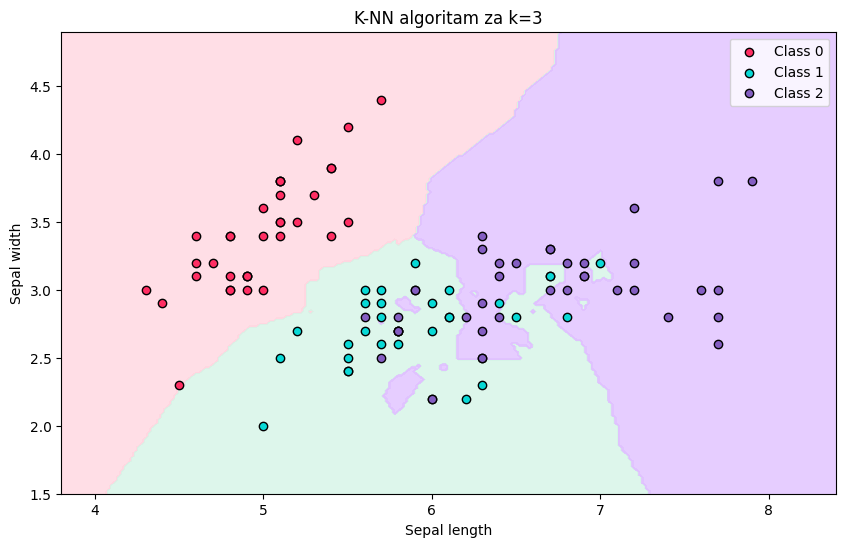

In [15]:
df = pd.read_csv('iris.csv')

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])


X = df.iloc[:, :2].values
y = df['species'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

background_colors =  ['#ffd6e0', '#d5f4e6', '#e0c1ff']
custom_cmap = ListedColormap(background_colors)

point_colors = ['#ff2e63', '#08d9d6', '#845ec2']

train_data = {'x': X_train, 'y': y_train}
knn = KNN(nb_features=2, nb_classes=3, data=train_data, k=3, weighted=False)
predictions = knn.predict({'x': X_test, 'y': y_test})


h = .02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = knn.predict({'x': grid_points, 'y': None})
grid_preds = np.array(grid_preds).reshape(xx.shape)


plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, grid_preds, cmap=custom_cmap, alpha=0.8)


for i, color in enumerate(point_colors):
    idx = np.where(y_train == i)
    plt.scatter(X_train[idx, 0], X_train[idx, 1], c=color, label=f'Class {i}', edgecolor='k')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('K-NN algoritam za k=3')
plt.legend()
plt.show()